In [18]:
!pip install sentence-transformers seaborn matplotlib

In [19]:
sentences = [

# Cricket
"The batsman hit a brilliant cover drive for four runs.",
"The bowler delivered a fast yorker that shattered the stumps.",
"The cricket team celebrated their victory after a thrilling match.",
"The captain set an aggressive field to pressure the batsman.",

# Cooking
"The chef added fresh herbs to enhance the flavor of the soup.",
"Baking a chocolate cake requires precise measurements of ingredients.",
"The vegetables were sautéed in olive oil and garlic.",
"A delicious pasta dish was prepared with creamy Alfredo sauce.",

# Cybersecurity
"Strong passwords are essential to protect online accounts.",
"Cybersecurity experts monitor networks to detect malicious activity."
]

In [20]:
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')

embeddings = model.encode(sentences)

print("Embedding shape:", embeddings.shape)

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Embedding shape: (10, 384)


In [21]:
from sklearn.metrics.pairwise import cosine_similarity

similarity_matrix = cosine_similarity(embeddings)

print(similarity_matrix)

[[ 1.0000004   0.4878332   0.37856317  0.539788    0.04104998  0.01911557
   0.01202627 -0.02143284  0.03205701 -0.00171858]
 [ 0.4878332   1.0000002   0.41068405  0.39477056  0.07959192  0.08873172
   0.00444528  0.05840731  0.03717774  0.0628916 ]
 [ 0.37856317  0.41068405  1.0000002   0.36470932  0.01503708 -0.05499443
   0.07469816  0.0134469  -0.06674603 -0.00712958]
 [ 0.539788    0.39477056  0.36470932  1.          0.04495764 -0.06979951
  -0.02001151 -0.03345903  0.03497025  0.02952098]
 [ 0.04104998  0.07959192  0.01503708  0.04495764  1.          0.09599715
   0.47355187  0.29031357 -0.00313004  0.03465285]
 [ 0.01911557  0.08873172 -0.05499443 -0.06979951  0.09599715  1.0000001
   0.06211238  0.0835539  -0.00881563  0.02134395]
 [ 0.01202627  0.00444528  0.07469816 -0.02001151  0.47355187  0.06211238
   1.0000001   0.28462803 -0.07551526 -0.01421805]
 [-0.02143284  0.05840731  0.0134469  -0.03345903  0.29031357  0.0835539
   0.28462803  1.0000001  -0.03610568  0.06021092]
 [

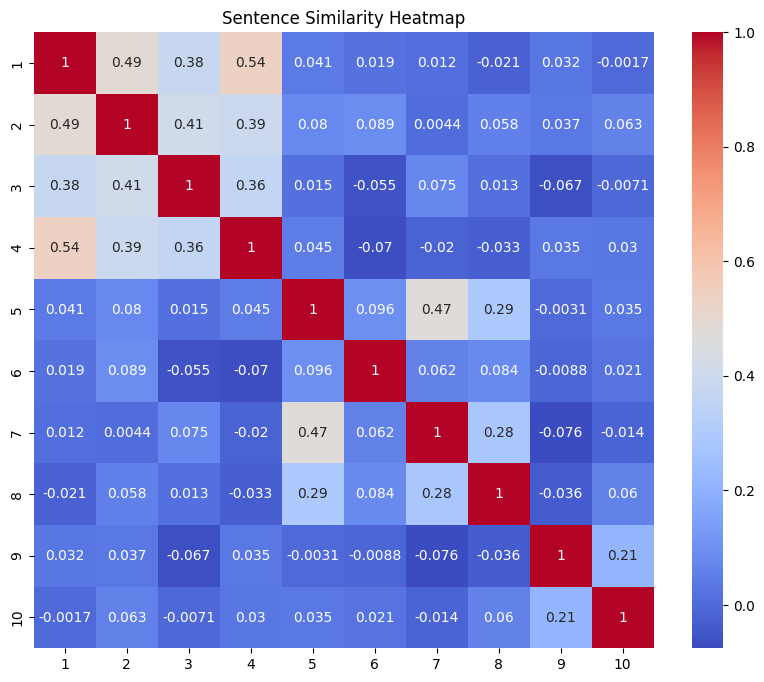

In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))

sns.heatmap(
    similarity_matrix,
    annot=True,
    cmap="coolwarm",
    xticklabels=range(1,11),
    yticklabels=range(1,11)
)

plt.title("Sentence Similarity Heatmap")
plt.show()

In [23]:
query = "The bowler took three wickets in one over"

query_embedding = model.encode([query])

query_similarity = cosine_similarity(query_embedding, embeddings)[0]

import numpy as np

top_indices = np.argsort(query_similarity)[-2:][::-1]

print("Query:", query)
print("\nTop 2 most similar sentences:\n")

for idx in top_indices:
    print(sentences[idx])
    print("Similarity Score:", query_similarity[idx])
    print()

Query: The bowler took three wickets in one over

Top 2 most similar sentences:

The bowler delivered a fast yorker that shattered the stumps.
Similarity Score: 0.62511826

The batsman hit a brilliant cover drive for four runs.
Similarity Score: 0.55569416

